In [ ]:
from __future__ import annotations

import operator
import os
import rem 
from datetime import date, datetime, timedelta
from pathlib import Path
from typing import TypedDict, List, Optional, Literal, Annotated
from pydantic import BaseModel, Field, ConfigDict

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.output_parsers import PydanticOutputParser
from langchain_community.tools.tavily_search import TavilySearchResults


In [ ]:

# -----------------------------
# 1) Schemas
# -----------------------------
class Task(BaseModel):
    model_config = ConfigDict(extra="ignore")
    
    id: int
    title: str
    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=1,
        max_length=6,
        description="3–6 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(..., description="Target word count for this section (120–550).")
    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False

class Plan(BaseModel):
    model_config = ConfigDict(extra="ignore")
    
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]

class EvidenceItem(BaseModel):
    model_config = ConfigDict(extra="ignore")
    
    title: str
    url: str
    published_at: Optional[str] = None
    snippet: Optional[str] = None
    source: Optional[str] = None

class RouterDecision(BaseModel):
    model_config = ConfigDict(extra="ignore")
    
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    reason: str
    queries: List[str] = Field(default_factory=list)
    max_results_per_query: int = Field(5, description="How many results to fetch per query (3–8).")

class EvidencePack(BaseModel):
    model_config = ConfigDict(extra="ignore")
    evidence: List[EvidenceItem] = Field(default_factory=list)

class State(TypedDict):
    topic: str
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]
    as_of: str
    recency_days: int
    sections: Annotated[List[tuple[int, str]], operator.add]
    final: str


In [ ]:

# -----------------------------
# 2) LLM Init (Groq Integration)
# -----------------------------
# Struct / Structured Mode for Pydantic Schema Parsing
llm_json = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.1,
    model_kwargs={"response_format": {"type": "json_object"}}
)

# Text Generation Mode for Markdown Writing
llm_text = ChatGroq(model="llama-3.1-8b-instant", temperature=0.3)

In [ ]:

# -----------------------------
# 3) Router Node
# -----------------------------
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.
Decide whether web research is needed BEFORE planning.
Modes:
- closed_book (needs_research=false): Evergreen topics where correctness does not depend on recent facts.
- hybrid (needs_research=true): Mostly evergreen but needs up-to-date examples/tools/models.
- open_book (needs_research=true): Mostly volatile: weekly roundups, latest news, rankings.

If needs_research=true:
- Output 3–10 high-signal queries.

{format_instructions}"""

def router_node(state: State) -> dict:
    topic = state["topic"]
    parser = PydanticOutputParser(pydantic_object=RouterDecision)
    sys_prompt = ROUTER_SYSTEM.format(format_instructions=parser.get_format_instructions())

    res = llm_json.invoke(
        [
            SystemMessage(content=sys_prompt),
            HumanMessage(content=f"Topic: {topic}\nAs-of date: {state['as_of']}"),
        ]
    )
    decision = parse_llm_json(res.content, parser)

    if decision.mode == "open_book":
        recency_days = 7
    elif decision.mode == "hybrid":
        recency_days = 45
    else:
        recency_days = 3650

    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
        "recency_days": recency_days,
    }

def route_next(state: State) -> str:
    return "research" if state["needs_research"] else "orchestrator"

In [ ]:

# -----------------------------
# 4) Research Node
# -----------------------------
def _tavily_search(query: str, max_results: int = 5) -> List[dict]:
    tool = TavilySearchResults(max_results=max_results)
    try:
        results = tool.invoke({"query": query})
    except Exception:
        results = []

    normalized: List[dict] = []
    for r in results or []:
        if isinstance(r, dict):
            normalized.append(
                {
                    "title": r.get("title") or "",
                    "url": r.get("url") or "",
                    "snippet": r.get("content") or r.get("snippet") or "",
                    "published_at": r.get("published_date") or r.get("published_at"),
                    "source": r.get("source"),
                }
            )
    return normalized

def _iso_to_date(s: Optional[str]) -> Optional[date]:
    if not s:
        return None
    try:
        return date.fromisoformat(s[:10])
    except Exception:
        return None

RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.
Given raw web search results, produce a deduplicated list of EvidenceItem objects.
Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources.
- Extract/normalize published_at as ISO (YYYY-MM-DD) if inferable.
- Keep snippets short.

{format_instructions}"""

def research_node(state: State) -> dict:
    queries = (state.get("queries", []) or [])[:10]
    raw_results: List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=5))

    if not raw_results:
        return {"evidence": []}

    parser = PydanticOutputParser(pydantic_object=EvidencePack)
    sys_prompt = RESEARCH_SYSTEM.format(format_instructions=parser.get_format_instructions())

    res = llm_json.invoke(
        [
            SystemMessage(content=sys_prompt),
            HumanMessage(
                content=(
                    f"As-of date: {state['as_of']}\n"
                    f"Recency days: {state['recency_days']}\n\n"
                    f"Raw results:\n{raw_results}"
                )
            ),
        ]
    )
    pack = parse_llm_json(res.content, parser)

    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e
    evidence = list(dedup.values())

    mode = state.get("mode", "closed_book")
    if mode == "open_book":
        as_of = date.fromisoformat(state["as_of"])
        cutoff = as_of - timedelta(days=int(state["recency_days"]))
        fresh: List[EvidenceItem] = []
        for e in evidence:
            d = _iso_to_date(e.published_at)
            if d and d >= cutoff:
                fresh.append(e)
        evidence = fresh

    return {"evidence": evidence}


In [ ]:
# -----------------------------
# 5) Orchestrator Node
# -----------------------------
ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Produce a highly actionable outline for a technical blog post (5–9 sections).

{format_instructions}"""

def orchestrator_node(state: State) -> dict:
    parser = PydanticOutputParser(pydantic_object=Plan)
    sys_prompt = ORCH_SYSTEM.format(format_instructions=parser.get_format_instructions())

    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")
    forced_kind = "news_roundup" if mode == "open_book" else None

    evidence_dumps = [e.model_dump() if hasattr(e, 'model_dump') else e for e in evidence]

    res = llm_json.invoke(
        [
            SystemMessage(content=sys_prompt),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n"
                    f"As-of: {state['as_of']} (recency_days={state['recency_days']})\n"
                    f"{'Force blog_kind=news_roundup' if forced_kind else ''}\n\n"
                    f"Evidence:\n{evidence_dumps[:16]}"
                )
            ),
        ]
    )
    plan = parse_llm_json(res.content, parser)

    if forced_kind:
        plan.blog_kind = "news_roundup"

    return {"plan": plan}

In [ ]:
# -----------------------------
# 6) Fanout Edge
# -----------------------------
def fanout(state: State):
    assert state["plan"] is not None
    evidence_dumps = [
        e.model_dump() if hasattr(e, 'model_dump') else e 
        for e in state.get("evidence", [])
    ]
    return [
        Send(
            "worker",
            {
                "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state["mode"],
                "as_of": state["as_of"],
                "recency_days": state["recency_days"],
                "plan": state["plan"].model_dump(),
                "evidence": evidence_dumps,
            },
        )
        for task in state["plan"].tasks
    ]

In [ ]:

# -----------------------------
# 7) Worker Node
# -----------------------------
WORKER_SYSTEM = """You are a senior technical writer. Write ONE section of a blog post in Markdown starting with '## <Section Title>'."""

def worker_node(payload: dict) -> dict:
    task = Task(**payload["task"])
    plan = Plan(**payload["plan"])
    raw_ev = payload.get("evidence", [])
    evidence = [e if isinstance(e, EvidenceItem) else EvidenceItem(**e) for e in raw_ev]

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:20]
        )

    # Note: Text section generation uses llm_text (not JSON constrained)
    section_md = llm_text.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {payload['topic']}\n"
                    f"Mode: {payload.get('mode', 'closed_book')}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence:\n{evidence_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [(task.id, section_md)]}

In [ ]:
# -----------------------------
# 8) Reducer Node
# -----------------------------
def reducer_node(state: State) -> dict:
    plan = state["plan"]
    if plan is None:
        raise ValueError("Reducer called without a plan.")

    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    final_md = f"# {plan.blog_title}\n\n{body}\n"

    safe_title = re.sub(r'[^\w\s-]', '', plan.blog_title).strip().replace(' ', '_')
    filename = f"{safe_title}.md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [ ]:
# -----------------------------
# 9) Build Graph
# -----------------------------
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_node)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

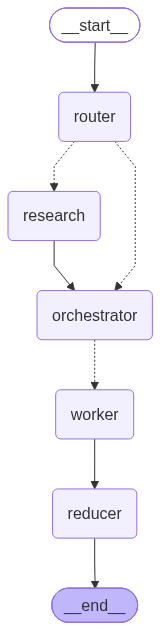

In [4]:
app

In [5]:
# -----------------------------
# 10) Runner
# -----------------------------
def run(topic: str, as_of: Optional[str] = None):
    if as_of is None:
        as_of = date.today().isoformat()

    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "as_of": as_of,
            "recency_days": 7,   # Router will update this if needed
            "sections": [],
            "final": "",
        }
    )

    plan: Optional[Plan] = out.get("plan")
    
    print("\n" + "=" * 80)
    print("TOPIC:", topic)
    print("AS_OF:", out.get("as_of"), "| RECENCY_DAYS:", out.get("recency_days"))
    print("MODE:", out.get("mode"))
    print("NEEDS_RESEARCH:", out.get("needs_research"))
    print("QUERIES:", (out.get("queries") or [])[:6])
    
    if plan:
        print("BLOG_KIND:", plan.blog_kind)
        print("TASKS:", len(plan.tasks))
    
    evidence = out.get("evidence", [])
    print("EVIDENCE_COUNT:", len(evidence))
    if evidence:
        sample_dumps = [e.model_dump() if hasattr(e, 'model_dump') else e for e in evidence[:2]]
        print("EVIDENCE_SAMPLE:", sample_dumps)
        
    print("SAVED_MD_CHARS:", len(out.get("final", "")))
    print("=" * 80 + "\n")

    return out

In [6]:
run("Write a blog on Self Attention")


TOPIC: Write a blog on Self Attention
AS_OF: 2026-07-30 | RECENCY_DAYS: 3650
MODE: closed_book
NEEDS_RESEARCH: False
QUERIES: []
BLOG_KIND: explainer
TASKS: 3
EVIDENCE_COUNT: 0
SAVED_MD_CHARS: 9384



{'topic': 'Write a blog on Self Attention',
 'mode': 'closed_book',
 'needs_research': False,
 'queries': [],
 'evidence': [],
 'plan': Plan(blog_title='Unlocking the Power of Self-Attention: A Deep Dive', audience='Machine Learning Engineers and Researchers', tone='Technical', blog_kind='explainer', constraints=['Closed-book', 'Recency: 3650 days'], tasks=[Task(id=1, title='Introduction to Self-Attention', goal='Understand the concept of self-attention and its role in transformer models.', bullets=['Define self-attention and its importance in transformer models.', 'Explain how self-attention works in the context of sequence-to-sequence tasks.', 'Discuss the benefits of self-attention over traditional recurrent neural networks (RNNs).', 'Provide examples of real-world applications of self-attention.'], target_words=250, tags=['Self-Attention', 'Transformer Models', 'Sequence-to-Sequence Tasks'], requires_research=False, requires_citations=False, requires_code=False), Task(id=2, title='